<h1>Chapter 6-Homework-Exercises</h1>

<p>Problem 1.</p>

<p>We want to estimate how different factors affect house prices. We collect data on:</p>

<p>Price (in $1000s) dependent variable<br />
	Size (square meters)<br />
	Bedrooms (number of bedrooms)<br />
	Age (years since construction)</p>

<p>Please estimate the regression below and evaluate the results:</p>

<p>Price = β0 + β1∙Size + β2∙Bedrooms + β3∙Age + ε</p>


In [2]:
# --------------------------------------------------
# Multiple Regression Example: Housing Prices
# --------------------------------------------------

# Import libraries
import pandas as pd
import statsmodels.api as sm

# Create dataset manually
data = {
    "Size": [50,60,80,100,120,140,160,180,70,90,110,130,150,170,200],
    "Bedrooms": [1,2,3,3,4,4,5,5,2,3,3,4,4,5,6],
    "Age": [20,15,10,5,8,3,2,1,12,9,7,6,4,2,1],
    "Price": [120,150,200,250,280,320,360,400,170,220,260,300,340,380,420]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display dataset
print(df)

# Define independent variables
X = df[["Size", "Bedrooms", "Age"]]
X = sm.add_constant(X)

# Define dependent variable
y = df["Price"]

# Estimate regression model
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())


    Size  Bedrooms  Age  Price
0     50         1   20    120
1     60         2   15    150
2     80         3   10    200
3    100         3    5    250
4    120         4    8    280
5    140         4    3    320
6    160         5    2    360
7    180         5    1    400
8     70         2   12    170
9     90         3    9    220
10   110         3    7    260
11   130         4    6    300
12   150         4    4    340
13   170         5    2    380
14   200         6    1    420
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     1779.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           4.70e-15
Time:                        17:34:04   Log-Likelihood:                -42.401
No. Observations:             

/usr/lib/python3/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


<p>Problem 2.</p>

<p>Write a Python program to complete the following tasks:</p>

<p>a. Import the dataset Chapter_06-cubic_cost_function.csv into Python and display the first few observations.</p>

<p>b. Create a scatter plot showing the relationship between total cost (TC) and quantity produced (q). Briefly describe the pattern we observe.</p>

<p>c. Generate two additional variables:<br />
	q2 (quantity squared)<br />
	q3 (quantity cubed)</p>

<p>Then compute and display the correlation matrix for q, q2, q3, and TC.</p>

<p>d. Estimate the following cubic cost function using ordinary least squares (OLS):</p>

<p>TC = β0 + β1∙q + β2∙q^2 + β3∙q^3 + ε</p>

<p>e. Interpret the regression results. In our answer, comment on:<br />
	The statistical significance of the coefficients<br />
	The overall fit of the model</p>
<p>Whether the estimated relationship is consistent with a typical total cost function


Dataset:
   Quantity   Total_Cost
0         1   902.581322
1         2   400.268559
2         3  1035.220830
3         4  1742.263885
4         5   343.927300


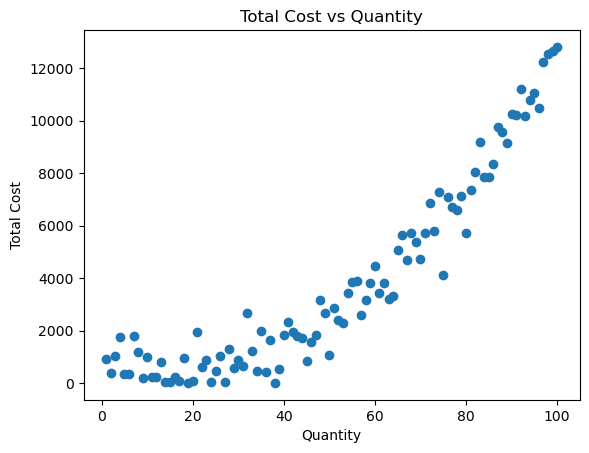


Dataset with Polynomial Terms:
   Quantity   Total_Cost  Quantity_sq  Quantity_cu
0         1   902.581322            1            1
1         2   400.268559            4            8
2         3  1035.220830            9           27
3         4  1742.263885           16           64
4         5   343.927300           25          125

Correlation Matrix:
             Quantity  Quantity_sq  Quantity_cu  Total_Cost
Quantity     1.000000     0.968854     0.917552    0.914236
Quantity_sq  0.968854     1.000000     0.986087    0.975385
Quantity_cu  0.917552     0.986087     1.000000    0.981617
Total_Cost   0.914236     0.975385     0.981617    1.000000

Regression Results:
                            OLS Regression Results                            
Dep. Variable:             Total_Cost   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     937.0
Date

In [3]:
# --------------------------------------------------
# Cubic Cost Function with Noise
# Data Import, Visualization, and Estimation
# --------------------------------------------------

# Step 1: Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# --------------------------------------------------
# Step 2: Load the dataset
# --------------------------------------------------

# Make sure the CSV file is in your working directory
df = pd.read_csv("Chapter_06-cubic_cost_function.csv")

# Display first few rows
print("Dataset:")
print(df.head())

# --------------------------------------------------
# Step 3: Plot Total Cost vs Quantity
# --------------------------------------------------

plt.figure()

# Scatter plot
plt.scatter(df["Quantity"], df["Total_Cost"])

# Labels and title
plt.xlabel("Quantity")
plt.ylabel("Total Cost")
plt.title("Total Cost vs Quantity")

plt.show()

# --------------------------------------------------
# Step 4: Create squared and cubic terms
# --------------------------------------------------

df["Quantity_sq"] = df["Quantity"]**2
df["Quantity_cu"] = df["Quantity"]**3

print("\nDataset with Polynomial Terms:")
print(df.head())

# --------------------------------------------------
# Step 5: Correlation Matrix
# --------------------------------------------------

corr_matrix = df[["Quantity", "Quantity_sq", "Quantity_cu", "Total_Cost"]].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# --------------------------------------------------
# Step 6: Estimate Cubic Regression Model
# --------------------------------------------------

# Define independent variables
X = df[["Quantity", "Quantity_sq", "Quantity_cu"]]
X = sm.add_constant(X)

# Dependent variable
y = df["Total_Cost"]

# Estimate model
model = sm.OLS(y, X).fit()

# Print regression results
print("\nRegression Results:")
print(model.summary())
